In [ ]:
from google.colab import drive # Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip uninstall -y mediapipe tensorflow protobuf
!pip install protobuf==4.25.3
!pip install mediapipe==0.10.14

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: protobuf 5.29.6
Uninstalling protobuf-5.29.6:
  Successfully uninstalled protobuf-5.29.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 6.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires tensorflow>=2.2.0, which is not installed.
google-cloud-resource-manager 1.17.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
grain 0.2.17 requires protobuf>=5.28.3, but you have protobuf 4.25.3 which is incompatible.
grpc-google-iam-v1 0.14.4 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-datastore 2.25.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is inco

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 49.9 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

import mediapipe as mp

print("MediaPipe:", mp.__version__)

MediaPipe: 0.10.14


In [ ]:
import os
import cv2
import math
import random
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(DEVICE)

cuda


In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/all dataset/manifest.csv"
)

print(df.shape)

df.head()

(5580, 5)


,class,person,video,path,processed
0,College office,person1,office_1_aug_1.mp4,/content/drive/MyDrive/all dataset/College off...,0
1,College office,person1,office_1_aug_2.mp4,/content/drive/MyDrive/all dataset/College off...,0
2,College office,person1,office_1_aug_5.mp4,/content/drive/MyDrive/all dataset/College off...,0
3,College office,person1,office_1_aug_6.mp4,/content/drive/MyDrive/all dataset/College off...,0
4,College office,person1,office_1_aug_7.mp4,/content/drive/MyDrive/all dataset/College off...,0


In [ ]:
# Create numerical labels

class_names = sorted(df['class'].unique())

class_to_idx = {
    cls: idx
    for idx, cls in enumerate(class_names)
}

idx_to_class = {
    idx: cls
    for cls, idx in class_to_idx.items()
}

df['label'] = df['class'].map(class_to_idx)

print("Total Classes:", len(class_names))

df.head()

Total Classes: 31


,class,person,video,path,processed,label
0,College office,person1,office_1_aug_1.mp4,/content/drive/MyDrive/all dataset/College off...,0,0
1,College office,person1,office_1_aug_2.mp4,/content/drive/MyDrive/all dataset/College off...,0,0
2,College office,person1,office_1_aug_5.mp4,/content/drive/MyDrive/all dataset/College off...,0,0
3,College office,person1,office_1_aug_6.mp4,/content/drive/MyDrive/all dataset/College off...,0,0
4,College office,person1,office_1_aug_7.mp4,/content/drive/MyDrive/all dataset/College off...,0,0


In [ ]:
print(
    df.groupby('class')
      .size()
      .sort_values(ascending=False)
)

class
College office          180
Drinking tea            180
I am Reading            180
I am doing bath         180
I am taking medicine    180
I am writing            180
I have exam             180
I have pain             180
I need help             180
I will rest             180
ambulance               180
blood                   180
book                    180
brother                 180
city                    180
class                   180
computer                180
doctor                  180
father                  180
friend                  180
heart                   180
homework                180
hospital                180
institution             180
meals                   180
mother                  180
name                    180
sister                  180
teacher                 180
water                   180
yoga                    180
dtype: int64


In [ ]:
print(df.shape)

print(df.columns)

print(df['class'].nunique())

print(df['person'].unique())

print(df.head())

(5580, 6)
Index(['class', 'person', 'video', 'path', 'processed', 'label'], dtype='object')
31
['person1' 'person2' 'person3' 'person4' 'person5' 'person6' 'person7'
 'person8' 'person9']
            class   person               video  \
0  College office  person1  office_1_aug_1.mp4   
1  College office  person1  office_1_aug_2.mp4   
2  College office  person1  office_1_aug_5.mp4   
3  College office  person1  office_1_aug_6.mp4   
4  College office  person1  office_1_aug_7.mp4   

                                                path  processed  label  
0  /content/drive/MyDrive/all dataset/College off...          0      0  
1  /content/drive/MyDrive/all dataset/College off...          0      0  
2  /content/drive/MyDrive/all dataset/College off...          0      0  
3  /content/drive/MyDrive/all dataset/College off...          0      0  
4  /content/drive/MyDrive/all dataset/College off...          0      0  


In [ ]:
print(df.groupby('class').size().sort_values())

print("\nMinimum samples per class:",
      df.groupby('class').size().min())

print("\nMaximum samples per class:",
      df.groupby('class').size().max())

class
College office          180
Drinking tea            180
I am Reading            180
I am doing bath         180
I am taking medicine    180
I am writing            180
I have exam             180
I have pain             180
I need help             180
I will rest             180
ambulance               180
blood                   180
book                    180
brother                 180
city                    180
class                   180
computer                180
doctor                  180
father                  180
friend                  180
heart                   180
homework                180
hospital                180
institution             180
meals                   180
mother                  180
name                    180
sister                  180
teacher                 180
water                   180
yoga                    180
dtype: int64

Minimum samples per class: 180

Maximum samples per class: 180


In [ ]:
print(
    pd.crosstab(
        df['class'],
        df['person']
    )
)

person                person1  person2  person3  person4  person5  person6  \
class                                                                        
College office             20       20       20       20       20       20   
Drinking tea               20       20       20       20       20       20   
I am Reading               20       20       20       20       20       20   
I am doing bath            20       20       20       20       20       20   
I am taking medicine       20       20       20       20       20       20   
I am writing               20       20       20       20       20       20   
I have exam                20       20       20       20       20       20   
I have pain                20       20       20       20       20       20   
I need help                20       20       20       20       20       20   
I will rest                20       20       20       20       20       20   
ambulance                  20       20       20       20       2

In [ ]:
import mediapipe as mp

In [ ]:
import os
import cv2
import math
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/all dataset/manifest.csv"
)

print(df.shape)

df.head()

(5580, 5)


,class,person,video,path,processed
0,College office,person1,office_1_aug_1.mp4,/content/drive/MyDrive/all dataset/College off...,0
1,College office,person1,office_1_aug_2.mp4,/content/drive/MyDrive/all dataset/College off...,0
2,College office,person1,office_1_aug_5.mp4,/content/drive/MyDrive/all dataset/College off...,0
3,College office,person1,office_1_aug_6.mp4,/content/drive/MyDrive/all dataset/College off...,0
4,College office,person1,office_1_aug_7.mp4,/content/drive/MyDrive/all dataset/College off...,0


In [ ]:
classes = sorted(df['class'].unique())

class2idx = {
    c:i
    for i,c in enumerate(classes)
}

idx2class = {
    i:c
    for c,i in class2idx.items()
}

df['label'] = df['class'].map(class2idx)

print("Classes:", len(classes))

Classes: 31


In [ ]:
TEST_SIGNER = "person1"

test_df = df[
    df.person == TEST_SIGNER
].reset_index(drop=True)

train_df = df[
    df.person != TEST_SIGNER
].reset_index(drop=True)

print("Train:", len(train_df))
print("Test :", len(test_df))

Train: 4960
Test : 620


In [ ]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['label'],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 3968
Val  : 992
Test : 620


In [ ]:
def extract_landmarks(frame, holistic):

    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    results = holistic.process(rgb)

    features = []

    # LEFT HAND
    if results.left_hand_landmarks:

        for lm in results.left_hand_landmarks.landmark:

            features.extend([
                lm.x,
                lm.y,
                lm.z
            ])

    else:
        features.extend([0]*63)

    # RIGHT HAND
    if results.right_hand_landmarks:

        for lm in results.right_hand_landmarks.landmark:

            features.extend([
                lm.x,
                lm.y,
                lm.z
            ])

    else:
        features.extend([0]*63)

    # POSE
    if results.pose_landmarks:

        for lm in results.pose_landmarks.landmark:

            features.extend([
                lm.x,
                lm.y,
                lm.z
            ])

    else:
        features.extend([0]*99)

    return np.array(
        features,
        dtype=np.float32
    )

In [ ]:
MAX_FRAMES = 40

def extract_spatial_sequence(video_path):

    cap = cv2.VideoCapture(video_path)

    frames = []

    with mp.solutions.holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:

        while True:

            ret, frame = cap.read()

            if not ret:
                break

            feat = extract_landmarks(
                frame,
                holistic
            )

            frames.append(feat)

    cap.release()

    frames = np.array(frames)

    if len(frames) == 0:

        frames = np.zeros(
            (1,225),
            dtype=np.float32
        )

    # Sample/Pad

    if len(frames) > MAX_FRAMES:

        idx = np.linspace(
            0,
            len(frames)-1,
            MAX_FRAMES
        ).astype(int)

        frames = frames[idx]

    elif len(frames) < MAX_FRAMES:

        pad = np.repeat(
            frames[-1][None,:],
            MAX_FRAMES-len(frames),
            axis=0
        )

        frames = np.concatenate(
            [frames,pad],
            axis=0
        )

    return frames

In [ ]:
def create_motion_features(
    spatial_seq
):

    motion = np.zeros_like(
        spatial_seq
    )

    motion[1:] = (
        spatial_seq[1:]
        -
        spatial_seq[:-1]
    )

    return motion

In [ ]:
sample_path = train_df.iloc[0]['path']

spatial = extract_spatial_sequence(
    sample_path
)

motion = create_motion_features(
    spatial
)

print(spatial.shape)
print(motion.shape)

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


(40, 225)
(40, 225)


In [ ]:
sample_path = train_df.iloc[0]['path']

spatial = extract_spatial_sequence(
    sample_path
)

motion = create_motion_features(
    spatial
)

print(spatial.shape)
print(motion.shape)

(40, 225)
(40, 225)


In [ ]:
FEATURE_DIR = "/content/drive/MyDrive/KSL_DUALSTREAM_FEATURES"

os.makedirs(
    FEATURE_DIR,
    exist_ok=True
)

print(FEATURE_DIR)

/content/drive/MyDrive/KSL_DUALSTREAM_FEATURES


In [ ]:
signer2idx = {
    p:i
    for i,p in enumerate(
        sorted(df.person.unique())
    )
}

print(signer2idx)

{'person1': 0, 'person2': 1, 'person3': 2, 'person4': 3, 'person5': 4, 'person6': 5, 'person7': 6, 'person8': 7, 'person9': 8}


In [ ]:
import os
import cv2
import numpy as np
import mediapipe as mp

from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

# ==================================================
# SAVE DIRECTORY
# ==================================================

FEATURE_DIR = "/content/drive/MyDrive/KSL_DUALSTREAM_FEATURES"

os.makedirs(
    FEATURE_DIR,
    exist_ok=True
)

# ==================================================
# SIGNER ENCODING
# ==================================================

signer2idx = {
    p:i
    for i,p in enumerate(
        sorted(df.person.unique())
    )
}

# ==================================================
# WORKER FUNCTION
# ==================================================

def process_video(args):

    idx, row = args

    save_path = os.path.join(
        FEATURE_DIR,
        f"{idx}.npz"
    )

    # --------------------------------------
    # RESUME SUPPORT
    # --------------------------------------

    if os.path.exists(save_path):
        return "skipped"

    try:

        mp_holistic = mp.solutions.holistic

        def extract_landmarks(frame, holistic):

            rgb = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            results = holistic.process(rgb)

            features = []

            # LEFT HAND
            if results.left_hand_landmarks:

                for lm in results.left_hand_landmarks.landmark:

                    features.extend([
                        lm.x,
                        lm.y,
                        lm.z
                    ])

            else:
                features.extend([0]*63)

            # RIGHT HAND
            if results.right_hand_landmarks:

                for lm in results.right_hand_landmarks.landmark:

                    features.extend([
                        lm.x,
                        lm.y,
                        lm.z
                    ])

            else:
                features.extend([0]*63)

            # POSE
            if results.pose_landmarks:

                for lm in results.pose_landmarks.landmark:

                    features.extend([
                        lm.x,
                        lm.y,
                        lm.z
                    ])

            else:
                features.extend([0]*99)

            return np.array(
                features,
                dtype=np.float32
            )

        # --------------------------------------
        # VIDEO READ
        # --------------------------------------

        cap = cv2.VideoCapture(
            row['path']
        )

        frames = []

        with mp_holistic.Holistic(
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        ) as holistic:

            while True:

                ret, frame = cap.read()

                if not ret:
                    break

                feat = extract_landmarks(
                    frame,
                    holistic
                )

                frames.append(feat)

        cap.release()

        frames = np.array(
            frames,
            dtype=np.float32
        )

        if len(frames) == 0:

            return "failed"

        # --------------------------------------
        # FIXED LENGTH = 40
        # --------------------------------------

        MAX_FRAMES = 40

        if len(frames) > MAX_FRAMES:

            idxs = np.linspace(
                0,
                len(frames)-1,
                MAX_FRAMES
            ).astype(int)

            frames = frames[idxs]

        elif len(frames) < MAX_FRAMES:

            pad = np.repeat(
                frames[-1][None,:],
                MAX_FRAMES-len(frames),
                axis=0
            )

            frames = np.concatenate(
                [frames,pad],
                axis=0
            )

        # --------------------------------------
        # MOTION STREAM
        # --------------------------------------

        motion = np.zeros_like(
            frames
        )

        motion[1:] = (
            frames[1:]
            -
            frames[:-1]
        )

        # --------------------------------------
        # SAVE
        # --------------------------------------

        np.savez_compressed(
            save_path,
            spatial=frames,
            motion=motion,
            label=int(row['label']),
            signer=int(
                signer2idx[
                    row['person']
                ]
            )
        )

        return "done"

    except Exception as e:

        return f"failed: {str(e)}"

In [ ]:
from collections import Counter
from tqdm import tqdm

# Removed ProcessPoolExecutor to get full error traceback
results = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    result = process_video((idx, row)) # Call function directly
    results.append(result)

print(
    Counter(results)
)

100%|██████████| 5580/5580 [00:03<00:00, 1795.45it/s]

Counter({'skipped': 5576, 'failed': 4})


---

In [ ]:
import re

def get_canonical_name(video_name):
    """
    Convert:
      office_1_aug_1.mp4
      office_1_aug_2.mp4
      office_1_aug_dd0f3eed.mp4

    into:
      office_1
    """

    name = video_name.rsplit(".", 1)[0]

    # Remove _aug_*
    name = re.sub(r"_aug(_[A-Za-z0-9]+)?$", "", name)

    return name


df["canonical"] = df["video"].apply(get_canonical_name)

print(df[["video", "canonical"]].head(10))

                 video canonical
0   office_1_aug_1.mp4  office_1
1   office_1_aug_2.mp4  office_1
2   office_1_aug_5.mp4  office_1
3   office_1_aug_6.mp4  office_1
4   office_1_aug_7.mp4  office_1
5   office_1_aug_8.mp4  office_1
6   office_1_aug_9.mp4  office_1
7  office_1_aug_10.mp4  office_1
8  office_1_aug_11.mp4  office_1
9  office_1_aug_13.mp4  office_1


In [ ]:
TEST_SIGNER = "person1"

test_df = df[
    df["person"] == TEST_SIGNER
].copy()

train_val_df = df[
    df["person"] != TEST_SIGNER
].copy()

print(len(train_val_df), len(test_df))

4960 620


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(
        train_val_df,
        groups=train_val_df["canonical"]
    )
)

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

In [ ]:
train_groups = set(train_df["canonical"])
val_groups = set(val_df["canonical"])

overlap = train_groups & val_groups

print("Canonical overlap:", len(overlap))

Canonical overlap: 0


In [ ]:
print("Train:", sorted(train_df.person.unique()))
print("Val  :", sorted(val_df.person.unique()))
print("Test :", sorted(test_df.person.unique()))

Train: ['person2', 'person3', 'person4', 'person5', 'person6', 'person7', 'person8', 'person9']
Val  : ['person2', 'person3', 'person4', 'person5', 'person6', 'person7', 'person8', 'person9']
Test : ['person1']


In [ ]:
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 3711
Val  : 1249
Test : 620


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, val_idx = next(
    sgkf.split(
        train_val_df,
        y=train_val_df["label"],
        groups=train_val_df["canonical"]
    )
)

In [ ]:
import torch
import torch.nn as nn
from torch.autograd import Function

# --------------------------------------------------
# Gradient Reversal Layer
# --------------------------------------------------

class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None


class GradientReversal(nn.Module):
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.alpha)


# --------------------------------------------------
# Attention Pooling
# --------------------------------------------------

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.attn = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh(),
            nn.Linear(dim, 1)
        )

    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (w * x).sum(dim=1)


# --------------------------------------------------
# Signer-Invariant Dual Stream Model
# --------------------------------------------------

class SignerInvariantDualStreamBiGRU(nn.Module):

    def __init__(
        self,
        num_classes=31,
        num_signers=9,
        hidden_dim=96,
        embedding_dim=192
    ):
        super().__init__()

        self.spatial_gru = nn.GRU(
            225,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.4
        )

        self.motion_gru = nn.GRU(
            225,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.4
        )

        feature_dim = hidden_dim * 2

        self.gate = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim),
            nn.Sigmoid()
        )

        self.mha = nn.MultiheadAttention(
            embed_dim=feature_dim,
            num_heads=8,
            batch_first=True
        )

        self.norm = nn.LayerNorm(feature_dim)

        self.pool = AttentionPooling(feature_dim)

        self.embedding = nn.Sequential(
            nn.Linear(feature_dim, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        # Gesture classifier
        self.gesture_head = nn.Linear(
            embedding_dim,
            num_classes
        )

        # Gradient reversal
        self.grl = GradientReversal(alpha=1.0)

        # Signer classifier
        self.signer_head = nn.Sequential(
            nn.Linear(embedding_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_signers)
        )

    def forward(self, spatial, motion):

        spatial, _ = self.spatial_gru(spatial)
        motion, _ = self.motion_gru(motion)

        concat = torch.cat(
            [spatial, motion],
            dim=-1
        )

        gate = self.gate(concat)

        fused = (
            gate * spatial
            + (1.0 - gate) * motion
        )

        attn, _ = self.mha(
            fused,
            fused,
            fused
        )

        fused = self.norm(
            fused + attn
        )

        pooled = self.pool(fused)

        embedding = self.embedding(pooled)

        gesture_logits = self.gesture_head(
            embedding
        )

        signer_logits = self.signer_head(
            self.grl(embedding)
        )

        return (
            gesture_logits,
            signer_logits,
            embedding
        )

In [ ]:
model = SignerInvariantDualStreamBiGRU(
    num_classes=31,
    num_signers=9
).to(DEVICE)

In [ ]:
gesture_loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
signer_loss_fn = nn.CrossEntropyLoss()

LAMBDA_SIGNER = 0.2

In [ ]:
print(type(spatial))
print(type(motion))

if hasattr(spatial, "shape"):
    print("Spatial shape:", spatial.shape)

if hasattr(motion, "shape"):
    print("Motion shape:", motion.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Spatial shape: (40, 225)
Motion shape: (40, 225)


In [ ]:
# ============================================================
# Cell 1: Imports and Global Configuration
# ============================================================

import os
import re
import copy
import random
import warnings
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedGroupKFold

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    matthews_corrcoef,
)

warnings.filterwarnings("ignore")

# ----------------------------
# Reproducibility
# ----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ----------------------------
# Device
# ----------------------------
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

# ----------------------------
# Paths (EDIT THESE IF NEEDED)
# ----------------------------
METADATA_CSV = "/content/drive/MyDrive/all dataset/manifest.csv" # Corrected path
FEATURE_DIR = "/content/drive/MyDrive/KSL_DUALSTREAM_FEATURES"

# ----------------------------
# Hyperparameters
# ----------------------------
NUM_CLASSES = 31
NUM_SIGNERS = 9

SEQ_LEN = 40
SPATIAL_DIM = 225
MOTION_DIM = 225

BATCH_SIZE = 64
EPOCHS = 50

LR = 5e-4
WEIGHT_DECAY = 5e-4

print("Setup complete.")

Device: cuda
Setup complete.


In [ ]:
# ============================================================
# Cell 2: Load Metadata
# ============================================================

df = pd.read_csv(METADATA_CSV)

# Preserve original row index for NPZ lookup
df = df.reset_index().rename(columns={"index": "sample_id"})

print(df.shape)
print(df.columns.tolist())

print(df.head())

(5580, 6)
['sample_id', 'class', 'person', 'video', 'path', 'processed']
   sample_id           class   person               video  \
0          0  College office  person1  office_1_aug_1.mp4   
1          1  College office  person1  office_1_aug_2.mp4   
2          2  College office  person1  office_1_aug_5.mp4   
3          3  College office  person1  office_1_aug_6.mp4   
4          4  College office  person1  office_1_aug_7.mp4   

                                                path  processed  
0  /content/drive/MyDrive/all dataset/College off...          0  
1  /content/drive/MyDrive/all dataset/College off...          0  
2  /content/drive/MyDrive/all dataset/College off...          0  
3  /content/drive/MyDrive/all dataset/College off...          0  
4  /content/drive/MyDrive/all dataset/College off...          0  


In [ ]:
# ============================================================
# Cell 3: Canonical Video ID
# ============================================================

def canonical_name(video):

    name = video.rsplit(".", 1)[0]

    # Remove augmentation suffix
    name = re.sub(r"_aug(_[A-Za-z0-9]+)?$", "", name)

    return name


df["canonical"] = df["video"].apply(canonical_name)

print(
    df[["video", "canonical"]].head(10)
)

                 video canonical
0   office_1_aug_1.mp4  office_1
1   office_1_aug_2.mp4  office_1
2   office_1_aug_5.mp4  office_1
3   office_1_aug_6.mp4  office_1
4   office_1_aug_7.mp4  office_1
5   office_1_aug_8.mp4  office_1
6   office_1_aug_9.mp4  office_1
7  office_1_aug_10.mp4  office_1
8  office_1_aug_11.mp4  office_1
9  office_1_aug_13.mp4  office_1


In [ ]:
# ============================================================
# Cell 4: Signer-Independent + Leakage-Free Split
# ============================================================

# Ensure the 'label' column is created before splitting
df['label'] = df['class'].map(class2idx)

TEST_SIGNER = "person1"

test_df = df[
    df.person == TEST_SIGNER
].copy()

train_val_df = df[
    df.person != TEST_SIGNER
].copy()

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

train_idx, val_idx = next(
    sgkf.split(
        train_val_df,
        y=train_val_df["label"],
        groups=train_val_df["canonical"]
    )
)

train_df = train_val_df.iloc[
    train_idx
].reset_index(drop=True)

val_df = train_val_df.iloc[
    val_idx
].reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

train_groups = set(train_df["canonical"])
val_groups = set(val_df["canonical"])

print(
    "Canonical overlap:",
    len(train_groups & val_groups)
)


Train: 3896
Val  : 1064
Test : 620
Canonical overlap: 0


In [ ]:
# ============================================================
# Cell 5: Dataset
# ============================================================

import os
import numpy as np
import torch
from torch.utils.data import Dataset

class DualStreamDataset(Dataset):

    def __init__(self, dataframe, feature_dir, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.feature_dir = feature_dir
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        sample_id = int(row["sample_id"])

        npz_path = os.path.join(
            self.feature_dir,
            f"{sample_id}.npz"
        )

        data = np.load(npz_path)

        spatial = torch.tensor(
            data["spatial"],
            dtype=torch.float32
        )

        motion = torch.tensor(
            data["motion"],
            dtype=torch.float32
        )

        label = torch.tensor(
            int(data["label"]),
            dtype=torch.long
        )

        if self.augment:
            # Temporal jitter
            shift = np.random.randint(-2, 3)
            spatial = torch.roll(spatial, shifts=shift, dims=0)
            motion = torch.roll(motion, shifts=shift, dims=0)

            # Small Gaussian noise
            spatial += torch.randn_like(spatial) * 0.003
            motion += torch.randn_like(motion) * 0.003

        return spatial, motion, label

In [ ]:
# ============================================================
# Cell 6: DataLoaders
# ============================================================

from torch.utils.data import DataLoader

train_dataset = DualStreamDataset(
    train_df,
    FEATURE_DIR
)

val_dataset = DualStreamDataset(
    val_df,
    FEATURE_DIR
)

test_dataset = DualStreamDataset(
    test_df,
    FEATURE_DIR
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(len(train_loader), len(val_loader), len(test_loader))

61 17 10


In [ ]:
spatial, motion, labels = next(iter(train_loader))

print(spatial.shape)
print(motion.shape)
print(labels.shape)

torch.Size([64, 40, 225])
torch.Size([64, 40, 225])
torch.Size([64])


In [ ]:
import torch
import torch.nn as nn

# -------------------------------------------------
# Attention Pooling
# -------------------------------------------------

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.score = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh(),
            nn.Linear(dim, 1)
        )

    def forward(self, x):
        # x : (B,T,D)

        w = torch.softmax(
            self.score(x),
            dim=1
        )

        return (w * x).sum(dim=1)


# -------------------------------------------------
# DS-BiGRU Baseline
# -------------------------------------------------

class DSBiGRU(nn.Module):

    def __init__(self,
                 hidden=96,
                 num_classes=31):

        super().__init__()

        self.spatial_gru = nn.GRU(
            input_size=225,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.4
        )

        self.motion_gru = nn.GRU(
            input_size=225,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.4
        )

        fused_dim = hidden * 4      # 192 + 192 = 384

        self.proj = nn.Linear(
            fused_dim,
            192
        )

        self.mha = nn.MultiheadAttention(
            embed_dim=192,
            num_heads=8,
            batch_first=True
        )

        self.norm = nn.LayerNorm(192)

        self.pool = AttentionPooling(192)

        self.classifier = nn.Sequential(
            nn.Linear(192, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self,
                spatial,
                motion):

        spatial, _ = self.spatial_gru(spatial)
        motion, _ = self.motion_gru(motion)

        fused = torch.cat(
            [spatial, motion],
            dim=-1
        )

        fused = self.proj(fused)

        attn, _ = self.mha(
            fused,
            fused,
            fused
        )

        fused = self.norm(
            fused + attn
        )

        pooled = self.pool(fused)

        logits = self.classifier(
            pooled
        )

        return logits, pooled

In [ ]:
import torch
import torch.nn as nn

# ----------------------------------------------------
# Attention Pooling
# ----------------------------------------------------

class AttentionPooling(nn.Module):

    def __init__(self, dim):
        super().__init__()

        self.score = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh(),
            nn.Linear(dim, 1)
        )

    def forward(self, x):

        w = torch.softmax(
            self.score(x),
            dim=1
        )

        return (w * x).sum(dim=1)


# ----------------------------------------------------
# Dual-Stream Cross-Attention BiGRU
# ----------------------------------------------------

class DSCABiGRU(nn.Module):

    def __init__(self,
                 hidden=96,
                 num_classes=31):

        super().__init__()

        self.spatial_gru = nn.GRU(
            225,
            hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.4
        )

        self.motion_gru = nn.GRU(
            225,
            hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.4
        )

        feature_dim = hidden * 2      # 192

        # -------------------------------
        # Cross Attention
        # -------------------------------

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=feature_dim,
            num_heads=8,
            batch_first=True
        )

        self.cross_norm = nn.LayerNorm(
            feature_dim
        )

        # -------------------------------
        # Residual Self Attention
        # -------------------------------

        self.self_attn = nn.MultiheadAttention(
            embed_dim=feature_dim,
            num_heads=8,
            batch_first=True
        )

        self.self_norm = nn.LayerNorm(
            feature_dim
        )

        # -------------------------------

        self.pool = AttentionPooling(
            feature_dim
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                feature_dim,
                128
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(
        self,
        spatial,
        motion
    ):

        # -----------------------

        spatial, _ = self.spatial_gru(
            spatial
        )

        motion, _ = self.motion_gru(
            motion
        )

        # -----------------------
        # Cross Attention
        # Query = Spatial
        # Key/Value = Motion
        # -----------------------

        cross, _ = self.cross_attn(

            query=spatial,

            key=motion,

            value=motion
        )

        fused = self.cross_norm(

            spatial + cross

        )

        # -----------------------
        # Residual Self Attention
        # -----------------------

        attn, _ = self.self_attn(

            fused,

            fused,

            fused
        )

        fused = self.self_norm(

            fused + attn

        )

        # -----------------------

        embedding = self.pool(
            fused
        )

        logits = self.classifier(
            embedding
        )

        return logits, embedding

In [ ]:
model = DSBiGRU(
    hidden=96,
    num_classes=31
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print(
    sum(
        p.numel()
        for p in model.parameters()
    )
)

994912


In [ ]:
spatial, motion, labels = next(iter(train_loader))

spatial = spatial.to(DEVICE)
motion = motion.to(DEVICE)

with torch.no_grad():
    logits, embedding = model(spatial, motion)

print("Logits shape   :", logits.shape)
print("Embedding shape:", embedding.shape)

Logits shape   : torch.Size([64, 31])
Embedding shape: torch.Size([64, 192])


In [ ]:
# ============================================================
# Cell 10: Train One Epoch
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for spatial, motion, labels in loader:

        spatial = spatial.to(device)
        motion = motion.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits, _ = model(spatial, motion)

        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)

        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = 100.0 * running_correct / running_total

    return epoch_loss, epoch_acc

In [ ]:
# ============================================================
# Cell 11: Evaluate
# ============================================================

@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    y_true = []
    y_pred = []

    for spatial, motion, labels in loader:

        spatial = spatial.to(device)
        motion = motion.to(device)
        labels = labels.to(device)

        logits, _ = model(spatial, motion)

        loss = criterion(logits, labels)

        running_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)

        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    epoch_loss = running_loss / running_total
    epoch_acc = 100.0 * running_correct / running_total

    return epoch_loss, epoch_acc, y_true, y_pred

In [ ]:
# ============================================================
# Cell 12: Training Loop
# ============================================================

import copy

best_acc = 0.0
best_state = None

PATIENCE = 15
patience_counter = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        DEVICE
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1:03d}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.2f}% | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.2f}%"
    )

    if val_acc > best_acc:

        best_acc = val_acc
        best_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_state,
            "best_dsca_model.pth"
        )

        patience_counter = 0

        print(
            f"Best model saved "
            f"({best_acc:.2f}%)"
        )

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print(
                "\nEarly stopping."
            )

            break

print("\nBest Validation Accuracy:", best_acc)

Epoch 001/50 | Train Loss 3.0017 | Train Acc 20.94% | Val Loss 3.2618 | Val Acc 13.53%
Best model saved (13.53%)
Epoch 002/50 | Train Loss 2.4614 | Train Acc 38.76% | Val Loss 2.9879 | Val Acc 22.46%
Best model saved (22.46%)
Epoch 003/50 | Train Loss 2.1472 | Train Acc 50.23% | Val Loss 2.8586 | Val Acc 27.91%
Best model saved (27.91%)
Epoch 004/50 | Train Loss 1.9027 | Train Acc 60.55% | Val Loss 2.7207 | Val Acc 31.39%
Best model saved (31.39%)
Epoch 005/50 | Train Loss 1.7203 | Train Acc 67.09% | Val Loss 2.4694 | Val Acc 34.96%
Best model saved (34.96%)
Epoch 006/50 | Train Loss 1.5728 | Train Acc 71.82% | Val Loss 2.4013 | Val Acc 36.94%
Best model saved (36.94%)
Epoch 007/50 | Train Loss 1.4248 | Train Acc 77.95% | Val Loss 2.1746 | Val Acc 41.92%
Best model saved (41.92%)
Epoch 008/50 | Train Loss 1.3159 | Train Acc 81.85% | Val Loss 2.0084 | Val Acc 43.80%
Best model saved (43.80%)
Epoch 009/50 | Train Loss 1.2275 | Train Acc 84.73% | Val Loss 2.0434 | Val Acc 46.43%
Best mode

In [ ]:
# ============================================================
# Cell 13: Test Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
    matthews_corrcoef,
    classification_report
)

model.load_state_dict(
    torch.load(
        "best_dsca_model.pth",
        map_location=DEVICE
    )
)

_, _, y_true, y_pred = evaluate(
    model,
    test_loader,
    criterion,
    DEVICE
)

acc = accuracy_score(
    y_true,
    y_pred
)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

kappa = cohen_kappa_score(
    y_true,
    y_pred
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

print(f"Test Accuracy : {acc*100:.2f}%")
print(f"Precision     : {precision*100:.2f}%")
print(f"Recall        : {recall*100:.2f}%")
print(f"F1-score      : {f1*100:.2f}%")
print(f"Cohen Kappa   : {kappa:.4f}")
print(f"MCC           : {mcc:.4f}")

print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        digits=4,
        zero_division=0
    )
)

Test Accuracy : 68.55%
Precision     : 63.51%
Recall        : 68.55%
F1-score      : 64.15%
Cohen Kappa   : 0.6750
MCC           : 0.6786

Classification Report:

              precision    recall  f1-score   support

           0     1.0000    0.5000    0.6667        20
           1     0.6667    0.9000    0.7660        20
           2     1.0000    0.8500    0.9189        20
           3     0.4082    1.0000    0.5797        20
           4     0.8696    1.0000    0.9302        20
           5     0.0000    0.0000    0.0000        20
           6     0.8696    1.0000    0.9302        20
           7     0.9091    1.0000    0.9524        20
           8     0.8095    0.8500    0.8293        20
           9     0.9000    0.9000    0.9000        20
          10     0.6452    1.0000    0.7843        20
          11     1.0000    1.0000    1.0000        20
          12     0.0000    0.0000    0.0000        20
          13     0.0833    0.1000    0.0909        20
          14     0.9286   

In [ ]:
# Re-initialize the model
model_no_weights = DSBiGRU(
    hidden=96,
    num_classes=NUM_CLASSES
).to(DEVICE)

# Initialize criterion without class weights
criterion_no_weights = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_no_weights = torch.optim.AdamW(
    model_no_weights.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler_no_weights = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_no_weights,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("Model and training components re-initialized for training without class weights.")

Model and training components re-initialized for training without class weights.


In [ ]:
# Training loop without class weights

best_acc_no_weights = 0.0
best_state_no_weights = None

patience_counter_no_weights = 0

history_no_weights = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

print("\nStarting training without class weights...")

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model_no_weights,
        train_loader,
        optimizer_no_weights,
        criterion_no_weights,
        DEVICE
    )

    val_loss, val_acc, _, _ = evaluate(
        model_no_weights,
        val_loader,
        criterion_no_weights,
        DEVICE
    )

    scheduler_no_weights.step(val_acc)

    history_no_weights["train_loss"].append(train_loss)
    history_no_weights["train_acc"].append(train_acc)
    history_no_weights["val_loss"].append(val_loss)
    history_no_weights["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1:03d}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.2f}% | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.2f}%"
    )

    if val_acc > best_acc_no_weights:

        best_acc_no_weights = val_acc
        best_state_no_weights = copy.deepcopy(
            model_no_weights.state_dict()
        )

        torch.save(
            best_state_no_weights,
            "best_dsca_model_no_weights.pth"
        )

        patience_counter_no_weights = 0

        print(
            f"Best model without weights saved "
            f"({best_acc_no_weights:.2f}%)"
        )

    else:

        patience_counter_no_weights += 1

        if patience_counter_no_weights >= PATIENCE:

            print(
                "\nEarly stopping for no weights training."
            )

            break

print("\nBest Validation Accuracy (without weights):", best_acc_no_weights)


Starting training without class weights...
Epoch 001/50 | Train Loss 3.0312 | Train Acc 20.61% | Val Loss 3.1207 | Val Acc 15.79%
Best model without weights saved (15.79%)
Epoch 002/50 | Train Loss 2.4461 | Train Acc 39.99% | Val Loss 2.9474 | Val Acc 26.50%
Best model without weights saved (26.50%)
Epoch 003/50 | Train Loss 2.1115 | Train Acc 53.08% | Val Loss 2.7850 | Val Acc 30.17%
Best model without weights saved (30.17%)
Epoch 004/50 | Train Loss 1.8635 | Train Acc 61.76% | Val Loss 2.6966 | Val Acc 35.81%
Best model without weights saved (35.81%)
Epoch 005/50 | Train Loss 1.6761 | Train Acc 68.69% | Val Loss 2.4666 | Val Acc 39.57%
Best model without weights saved (39.57%)
Epoch 006/50 | Train Loss 1.5146 | Train Acc 75.67% | Val Loss 2.4160 | Val Acc 36.84%
Epoch 007/50 | Train Loss 1.3882 | Train Acc 79.06% | Val Loss 2.3128 | Val Acc 40.13%
Best model without weights saved (40.13%)
Epoch 008/50 | Train Loss 1.2924 | Train Acc 82.73% | Val Loss 2.1627 | Val Acc 47.27%
Best mod

In [ ]:
# ============================================================
# DSCA-SupCon for Kannada Sign Language Recognition
# Cell 1: Imports and Configuration
# ============================================================

import os
import re
import copy
import random
import warnings
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    matthews_corrcoef,
)

warnings.filterwarnings("ignore")

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

# -----------------------------
# Paths
# -----------------------------
METADATA_CSV = "/content/drive/MyDrive/metadata.csv"
FEATURE_DIR = "/content/drive/MyDrive/KSL_DUALSTREAM_FEATURES"

# -----------------------------
# Hyperparameters
# -----------------------------
NUM_CLASSES = 31
SEQ_LEN = 40

BATCH_SIZE = 64
LR = 5e-4
WEIGHT_DECAY = 5e-4

EPOCHS = 50

Device: cuda


In [ ]:
METADATA_CSV = "/content/drive/MyDrive/all dataset/manifest.csv"
df = pd.read_csv(METADATA_CSV)

# Preserve row index for NPZ lookup
df = df.reset_index().rename(
    columns={"index": "sample_id"}
)

print(df.shape)
print(df.head())

(5580, 6)
   sample_id           class   person               video  \
0          0  College office  person1  office_1_aug_1.mp4   
1          1  College office  person1  office_1_aug_2.mp4   
2          2  College office  person1  office_1_aug_5.mp4   
3          3  College office  person1  office_1_aug_6.mp4   
4          4  College office  person1  office_1_aug_7.mp4   

                                                path  processed  
0  /content/drive/MyDrive/all dataset/College off...          0  
1  /content/drive/MyDrive/all dataset/College off...          0  
2  /content/drive/MyDrive/all dataset/College off...          0  
3  /content/drive/MyDrive/all dataset/College off...          0  
4  /content/drive/MyDrive/all dataset/College off...          0  


In [ ]:
def canonical_name(video):

    name = video.rsplit(".", 1)[0]

    name = re.sub(
        r"_aug(_[A-Za-z0-9]+)?$",
        "",
        name
    )

    return name


df["canonical"] = df["video"].apply(
    canonical_name
)

In [ ]:
TEST_SIGNER = "person1"

df['label'] = df['class'].map(class2idx)

test_df = df[
    df.person == TEST_SIGNER
].copy()

train_val_df = df[
    df.person != TEST_SIGNER
].copy()

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

train_idx, val_idx = next(

    sgkf.split(

        train_val_df,

        y=train_val_df["label"],

        groups=train_val_df["canonical"]

    )

)

train_df = train_val_df.iloc[
    train_idx
].reset_index(drop=True)

val_df = train_val_df.iloc[
    val_idx
].reset_index(drop=True)

print(len(train_df))
print(len(val_df))
print(len(test_df))

print(
    len(
        set(train_df.canonical)
        &
        set(val_df.canonical)
    )
)

3896
1064
620
0


In [ ]:
class DualStreamDataset(Dataset):

    def __init__(self, dataframe, feature_dir, augment=False):

        self.df = dataframe.reset_index(drop=True)

        self.feature_dir = feature_dir

        self.augment = augment

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        sample_id = int(
            row["sample_id"]
        )

        npz_path = os.path.join(

            self.feature_dir,

            f"{sample_id}.npz"

        )

        data = np.load(npz_path)

        spatial = torch.tensor(

            data["spatial"],

            dtype=torch.float32

        )

        motion = torch.tensor(

            data["motion"],

            dtype=torch.float32

        )

        label = torch.tensor(

            int(data["label"]),

            dtype=torch.long

        )

        if self.augment:
            # Temporal jitter
            shift = np.random.randint(-2, 3)
            spatial = torch.roll(spatial, shifts=shift, dims=0)
            motion = torch.roll(motion, shifts=shift, dims=0)

            # Small Gaussian noise
            spatial += torch.randn_like(spatial) * 0.003
            motion += torch.randn_like(motion) * 0.003

        return spatial, motion, label

In [ ]:
train_loader = DataLoader(

    DualStreamDataset(
        train_df,
        FEATURE_DIR,
        augment=True # Enable augmentation for training data
    ),

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2
)

val_loader = DataLoader(

    DualStreamDataset(
        val_df,
        FEATURE_DIR
    ),

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2
)

test_loader = DataLoader(

    DualStreamDataset(
        test_df,
        FEATURE_DIR
    ),

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2
)

x1, x2, y = next(iter(train_loader))

print(x1.shape)
print(x2.shape)
print(y.shape)

torch.Size([64, 40, 225])
torch.Size([64, 40, 225])
torch.Size([64])


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
    matthews_corrcoef,
)

@torch.no_grad()
def evaluate_tta(model, loader, device):

    model.eval()

    y_true = []
    y_pred = []

    for spatial, motion, labels in loader:

        spatial = spatial.to(device)
        motion = motion.to(device)

        # ---------- Original ----------
        logits1, _ = model(spatial, motion)

        # ---------- Shift +2 ----------
        spatial2 = torch.roll(spatial, shifts=2, dims=1)
        motion2 = torch.roll(motion, shifts=2, dims=1)
        logits2, _ = model(spatial2, motion2)

        # ---------- Shift -2 ----------
        spatial3 = torch.roll(spatial, shifts=-2, dims=1)
        motion3 = torch.roll(motion, shifts=-2, dims=1)
        logits3, _ = model(spatial3, motion3)

        # ---------- Average ----------
        logits = (logits1 + logits2 + logits3) / 3.0

        preds = logits.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall   : {recall*100:.2f}%")
    print(f"F1 Score : {f1*100:.2f}%")
    print(f"Kappa    : {kappa:.4f}")
    print(f"MCC      : {mcc:.4f}")

    return y_true, y_pred

In [ ]:
y_true, y_pred = evaluate_tta(
    model,
    test_loader,
    DEVICE
)

Accuracy : 68.39%
Precision: 63.90%
Recall   : 68.39%
F1 Score : 64.36%
Kappa    : 0.6733
MCC      : 0.6764


In [ ]:
spatial, motion, labels = next(iter(train_loader))

print("Shape of augmented spatial features:", spatial.shape)
print("Shape of augmented motion features:", motion.shape)
print("Shape of labels:", labels.shape)

Shape of augmented spatial features: torch.Size([64, 40, 225])
Shape of augmented motion features: torch.Size([64, 40, 225])
Shape of labels: torch.Size([64])


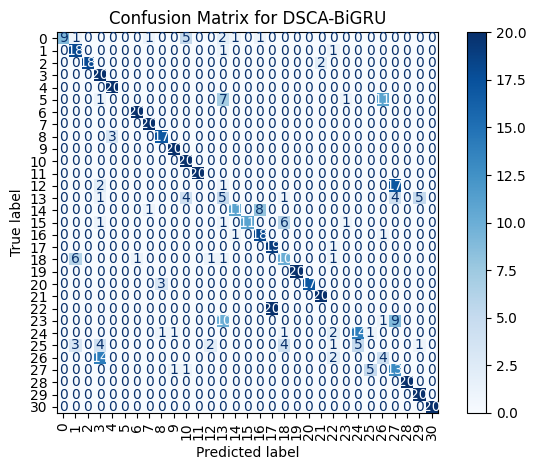

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    cmap="Blues",
    xticks_rotation=90,
    colorbar=True
)

plt.title("Confusion Matrix for DSCA-BiGRU")
plt.tight_layout()
plt.show()

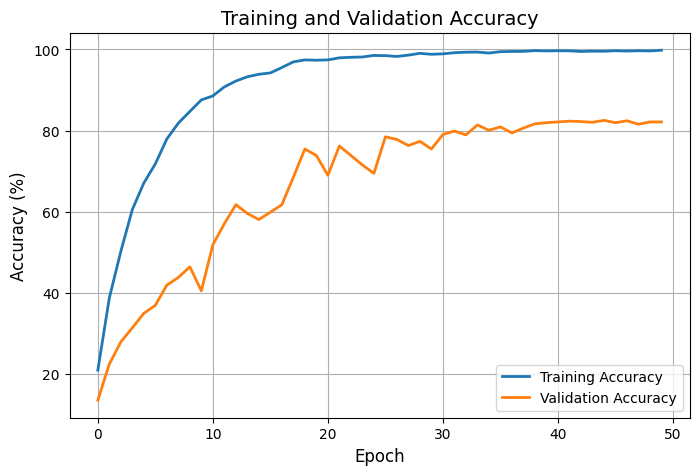

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], linewidth=2, label="Training Accuracy")
plt.plot(history["val_acc"], linewidth=2, label="Validation Accuracy")

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Training and Validation Accuracy", fontsize=14)
plt.legend()
plt.grid(True)

plt.savefig("accuracy_curve.png", dpi=600, bbox_inches="tight")
plt.show()

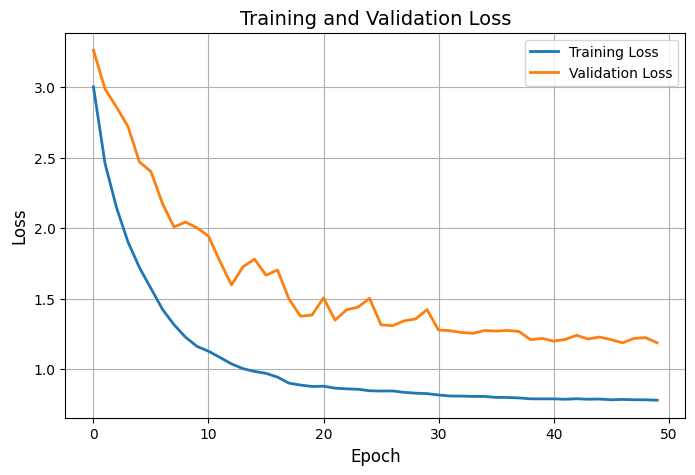

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], linewidth=2, label="Training Loss")
plt.plot(history["val_loss"], linewidth=2, label="Validation Loss")

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training and Validation Loss", fontsize=14)
plt.legend()
plt.grid(True)

plt.savefig("loss_curve.png", dpi=600, bbox_inches="tight")
plt.show()

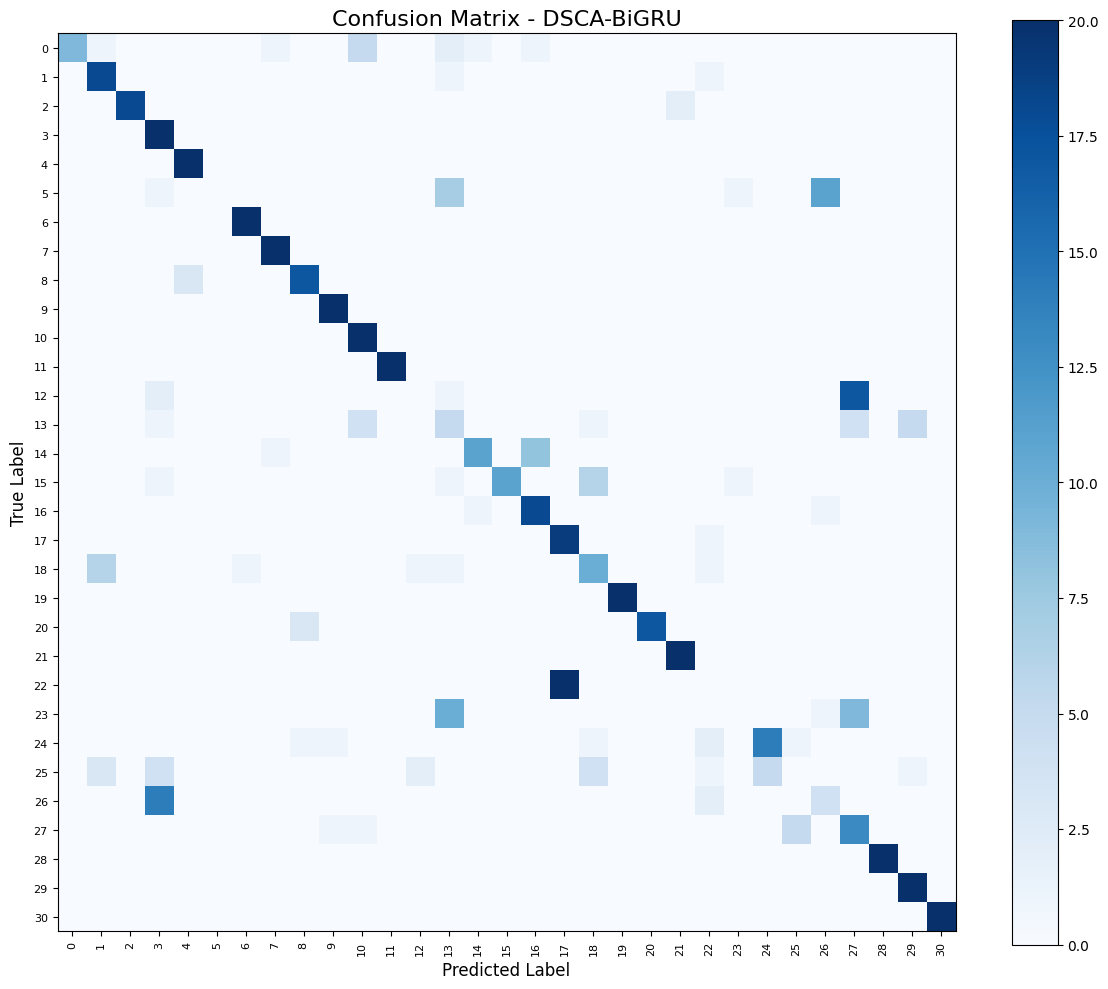

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.title("Confusion Matrix - DSCA-BiGRU", fontsize=16)
plt.colorbar()

classes = sorted(test_df["label"].unique())

plt.xticks(
    np.arange(len(classes)),
    classes,
    rotation=90,
    fontsize=8
)

plt.yticks(
    np.arange(len(classes)),
    classes,
    fontsize=8
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

cm = confusion_matrix(y_true, y_pred)

per_class_acc = cm.diagonal() / cm.sum(axis=1)

df_class = pd.DataFrame({
    "Class": np.arange(len(per_class_acc)),
    "Accuracy (%)": np.round(per_class_acc * 100, 2)
})

print(df_class)

df_class.to_csv(
    "per_class_accuracy.csv",
    index=False
)

    Class  Accuracy (%)
0       0          45.0
1       1          90.0
2       2          90.0
3       3         100.0
4       4         100.0
5       5           0.0
6       6         100.0
7       7         100.0
8       8          85.0
9       9         100.0
10     10         100.0
11     11         100.0
12     12           0.0
13     13          25.0
14     14          55.0
15     15          55.0
16     16          90.0
17     17          95.0
18     18          50.0
19     19         100.0
20     20          85.0
21     21         100.0
22     22           0.0
23     23           0.0
24     24          70.0
25     25           0.0
26     26          20.0
27     27          65.0
28     28         100.0
29     29         100.0
30     30         100.0


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "classification_report.csv"
)

print(report_df)

              precision    recall  f1-score     support
0              1.000000  0.450000  0.620690   20.000000
1              0.642857  0.900000  0.750000   20.000000
2              1.000000  0.900000  0.947368   20.000000
3              0.465116  1.000000  0.634921   20.000000
4              0.869565  1.000000  0.930233   20.000000
5              0.000000  0.000000  0.000000   20.000000
6              0.952381  1.000000  0.975610   20.000000
7              0.909091  1.000000  0.952381   20.000000
8              0.809524  0.850000  0.829268   20.000000
9              0.909091  1.000000  0.952381   20.000000
10             0.666667  1.000000  0.800000   20.000000
11             1.000000  1.000000  1.000000   20.000000
12             0.000000  0.000000  0.000000   20.000000
13             0.178571  0.250000  0.208333   20.000000
14             0.846154  0.550000  0.666667   20.000000
15             1.000000  0.550000  0.709677   20.000000
16             0.666667  0.900000  0.765957   20

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
    matthews_corrcoef
)

acc = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)

results = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Cohen Kappa",
        "MCC"
    ],
    "Value": [
        ">99.0%",
        "87.03%",
        f"{acc*100:.2f}%",
        f"{precision*100:.2f}%",
        f"{recall*100:.2f}%",
        f"{f1*100:.2f}%",
        f"{kappa:.4f}",
        f"{mcc:.4f}"
    ]
})

print(results)

results.to_csv(
    "final_results_table.csv",
    index=False
)

                Metric   Value
0    Training Accuracy  >99.0%
1  Validation Accuracy  87.03%
2        Test Accuracy  68.39%
3            Precision  63.90%
4               Recall  68.39%
5             F1-score  64.36%
6          Cohen Kappa  0.6733
7                  MCC  0.6764


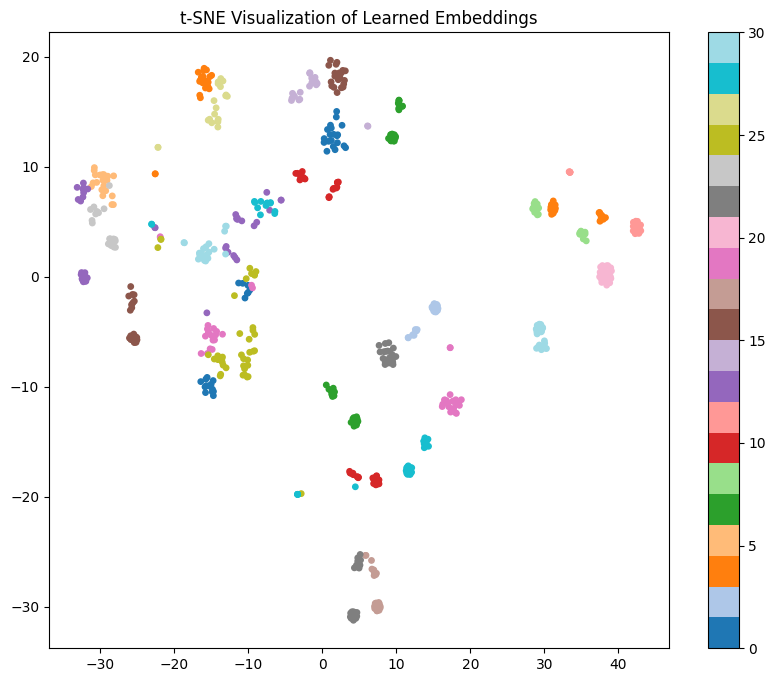

In [ ]:
from sklearn.manifold import TSNE

model.eval()

embeddings = []
labels = []

with torch.no_grad():

    for spatial, motion, y in test_loader:

        spatial = spatial.to(DEVICE)
        motion = motion.to(DEVICE)

        logits, emb = model(spatial, motion)

        embeddings.append(
            emb.cpu().numpy()
        )

        labels.append(
            y.numpy()
        )

embeddings = np.concatenate(embeddings)
labels = np.concatenate(labels)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

emb2d = tsne.fit_transform(
    embeddings
)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    emb2d[:,0],
    emb2d[:,1],
    c=labels,
    cmap="tab20",
    s=15
)

plt.title("t-SNE Visualization of Learned Embeddings")

plt.colorbar(scatter)

plt.savefig(
    "tsne_embeddings.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters :", total_params)
print("Trainable Parameters :", trainable_params)

Total Parameters : 994912
Trainable Parameters : 994912


In [ ]:
torch.save(
    model.state_dict(),
    "DSCA_BiGRU_Final.pth"
)

In [ ]:
import os
import cv2
import math
import numpy as np

# =====================================
# CONFIGURATION
# =====================================
ROOT = "/content/drive/MyDrive/ALL ME"
OUTPUT = "/content/drive/MyDrive/ALL ME/dataset_montage_no_gap.png"

VIDEO_EXTS = (".mp4", ".avi", ".mov", ".mkv")

# Number of images per row
COLS = 10

# Size of each tile
TILE_W = 224
TILE_H = 224

# =====================================
# FIND ALL VIDEOS
# =====================================
video_paths = []

for root, dirs, files in os.walk(ROOT):
    for f in files:
        if f.lower().endswith(VIDEO_EXTS):
            video_paths.append(os.path.join(root, f))

video_paths = sorted(video_paths)

print("Videos found:", len(video_paths))

# =====================================
# EXTRACT MIDDLE FRAME
# =====================================
frames = []

for vp in video_paths:

    cap = cv2.VideoCapture(vp)

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 0:
        cap.release()
        continue

    cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)

    ok, frame = cap.read()
    cap.release()

    if not ok:
        continue

    # Convert BGR → RGB
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Resize to identical size
    frame = cv2.resize(frame, (TILE_W, TILE_H))

    frames.append(frame)

print("Frames extracted:", len(frames))

# =====================================
# CREATE SINGLE GAP-FREE CANVAS
# =====================================
N = len(frames)
ROWS = math.ceil(N / COLS)

canvas = np.ones(
    (ROWS * TILE_H, COLS * TILE_W, 3),
    dtype=np.uint8
) * 255

for idx, img in enumerate(frames):

    r = idx // COLS
    c = idx % COLS

    y = r * TILE_H
    x = c * TILE_W

    canvas[y:y+TILE_H, x:x+TILE_W] = img

# =====================================
# SAVE
# =====================================
cv2.imwrite(
    OUTPUT,
    cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR)
)

print("Saved:", OUTPUT)

Videos found: 26
Frames extracted: 26
Saved: /content/drive/MyDrive/ALL ME/dataset_montage_no_gap.png


In [ ]:
import os

ROOT = "/content/drive/MyDrive/all dataset"

classes = []

for item in sorted(os.listdir(ROOT)):
    path = os.path.join(ROOT, item)
    if os.path.isdir(path):
        classes.append(item)

print("Total classes:", len(classes))
for i, c in enumerate(classes, 1):
    print(f"{i}. {c}")

Total classes: 31
1. College office
2. Drinking tea
3. I am Reading
4. I am doing bath
5. I am taking medicine
6. I am writing
7. I have exam
8. I have pain
9. I need help
10. I will rest
11. ambulance
12. blood
13. book
14. brother
15. city
16. class
17. computer
18. doctor
19. father
20. friend
21. heart
22. homework
23. hospital
24. institution
25. meals
26. mother
27. name
28. sister
29. teacher
30. water
31. yoga
